In [13]:
# Sales Data Analysis
# CloudExify Data Science Internship — Month 1, Project 1

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('sample_data.csv')

print(df.head())
print(df.shape)
print(df.info())
print(df.describe())

         Date  Product     Category Region  Units   Amount
0   4/13/2025  Printer  Accessories   East     10  25532.0
1  12/15/2025    Mouse  Accessories  North     14  38346.0
2   9/28/2025   Laptop  Electronics  South     11  45436.0
3   4/17/2025  Monitor  Peripherals   West     18  30294.0
4   3/13/2025   Tablet  Peripherals  South     12   5948.0
(510, 6)
<class 'pandas.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      510 non-null    str    
 1   Product   510 non-null    str    
 2   Category  510 non-null    str    
 3   Region    510 non-null    str    
 4   Units     510 non-null    int64  
 5   Amount    495 non-null    float64
dtypes: float64(1), int64(1), str(4)
memory usage: 24.0 KB
None
            Units        Amount
count  510.000000    495.000000
mean     9.800000  25699.985859
std      5.490767  13931.159621
min      1.000000    661.000000
25%     

In [15]:
print("Missing values:\n", df.isnull().sum())

df = df.dropna()
df = df.drop_duplicates()
df['Date'] = pd.to_datetime(df['Date'])

print("\nAfter cleaning:", df.shape)
print(df.dtypes)

Missing values:
 Date         0
Product      0
Category     0
Region       0
Units        0
Amount      15
dtype: int64

After cleaning: (485, 6)
Date        datetime64[us]
Product                str
Category               str
Region                 str
Units                int64
Amount             float64
dtype: object


In [16]:
print("Total Revenue: Rs", df['Amount'].sum())
print("Avg Sale: Rs", df['Amount'].mean())
print("Median Sale: Rs", df['Amount'].median())
print("Std Dev: Rs", df['Amount'].std())

print("\nProduct counts:\n", df['Product'].value_counts())

by_product = df.groupby('Product')['Amount'].sum().sort_values(ascending=False)
print("\nRevenue by product:\n", by_product.head(10))

Total Revenue: Rs 12423188.0
Avg Sale: Rs 25614.8206185567
Median Sale: Rs 25970.0
Std Dev: Rs 13844.751578688838

Product counts:
 Product
Laptop        60
Headphones    58
Charger       53
Keyboard      51
Speaker       49
Webcam        48
Mouse         44
Printer       41
Tablet        41
Monitor       40
Name: count, dtype: int64

Revenue by product:
 Product
Laptop        1627608.0
Webcam        1376670.0
Headphones    1355870.0
Charger       1287786.0
Keyboard      1238179.0
Mouse         1183136.0
Speaker       1143508.0
Printer       1128049.0
Tablet        1079738.0
Monitor       1002644.0
Name: Amount, dtype: float64


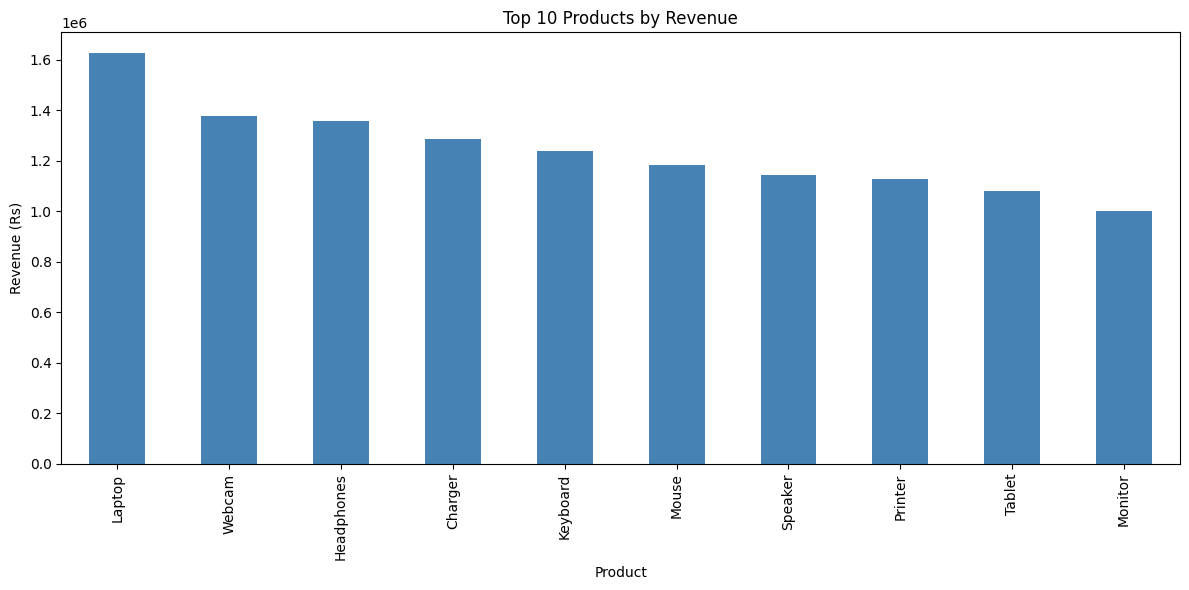

In [17]:
top_products = df.groupby('Product')['Amount'].sum().nlargest(10)
top_products.plot(kind='bar', figsize=(12, 6), color='steelblue')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue (Rs)')
plt.tight_layout()
plt.show()

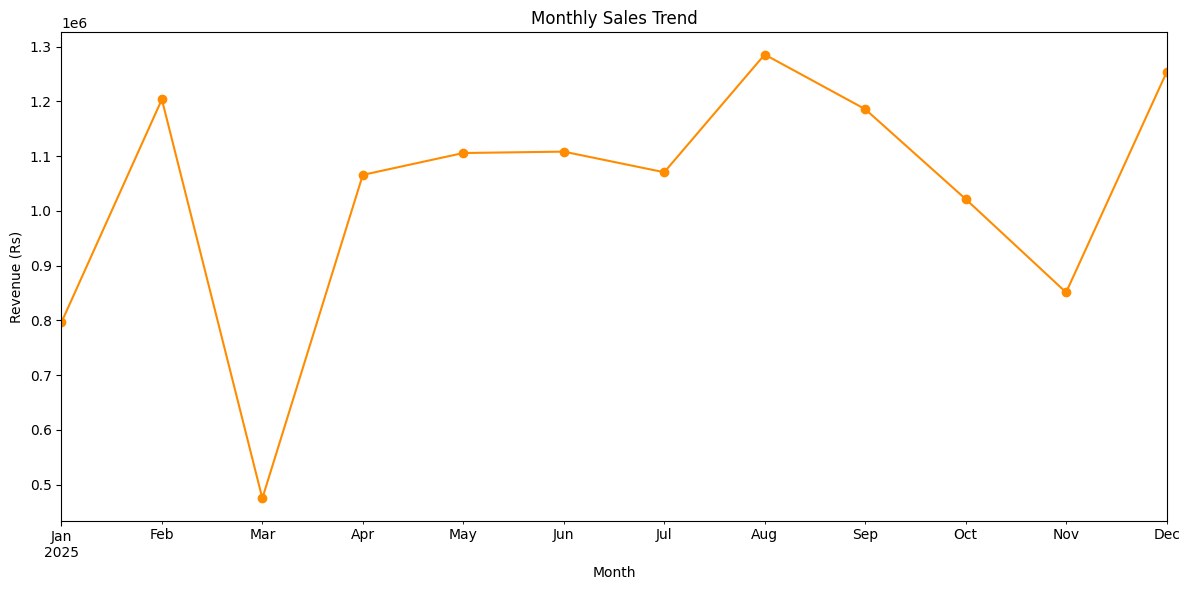

In [18]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum()
monthly_sales.plot(kind='line', figsize=(12, 6), marker='o', color='darkorange')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (Rs)')
plt.tight_layout()
plt.show()

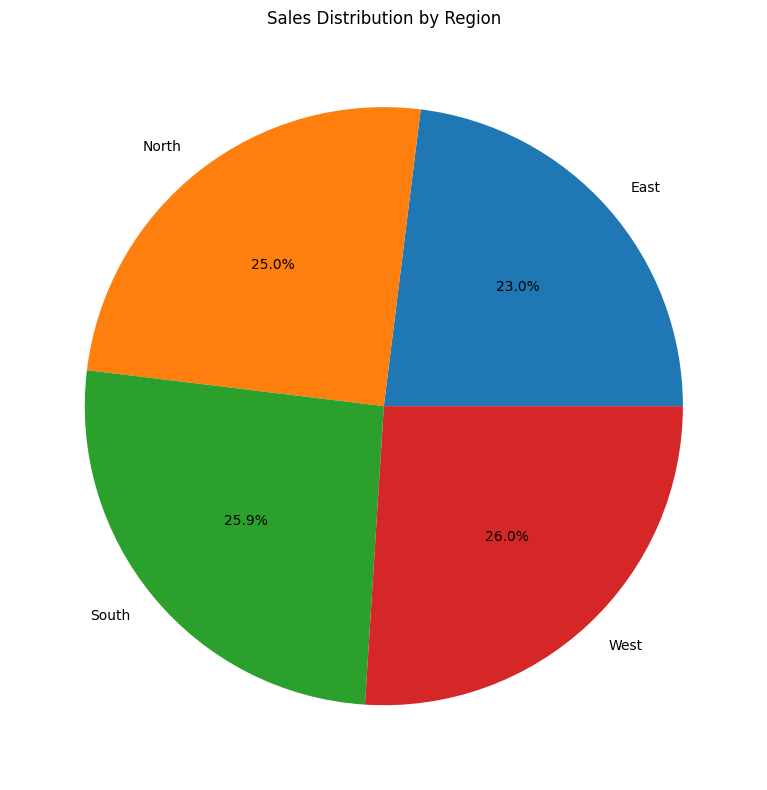

In [19]:
by_region = df.groupby('Region')['Amount'].sum()
by_region.plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8))
plt.title('Sales Distribution by Region')
plt.ylabel('')
plt.tight_layout()
plt.show()

                Amount  Units
Category                     
Accessories  3859478.0   1587
Electronics  4201471.0   1509
Peripherals  4362239.0   1662


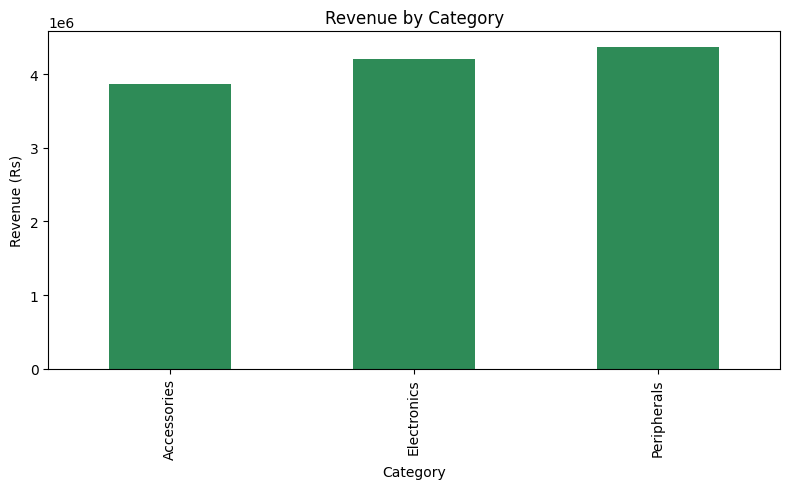

In [22]:
by_category = df.groupby('Category').agg({'Amount': 'sum', 'Units': 'sum'})
print(by_category)

by_category['Amount'].plot(kind='bar', figsize=(8, 5), color='seagreen')
plt.title('Revenue by Category')
plt.ylabel('Revenue (Rs)')
plt.tight_layout()
plt.show()